# Eyes-Open vs. Eyes-Closed (Alpha Blocking) Demo

This notebook demonstrates a classic EEG paradigm: **Alpha Blocking** (also called Eyes-Open / Eyes-Closed).

## Background
- When the eyes are **closed** and the subject is relaxed, the occipital cortex typically generates strong **Alpha waves** (8–13 Hz).
- When the eyes are **opened**, visual input suppresses ("blocks") this Alpha activity.
- This makes the Alpha band an excellent biomarker for distinguishing between resting and active visual states.

## Dataset
- `open_closed_eye2.txt` — recorded via NeuraDock Bluetooth protocol
- 7 channels, ~53 seconds, 250 Hz sampling rate
- The experiment protocol alternates between eyes-open and eyes-closed periods.

## Pipeline
1. Load raw text data
2. Quick visual inspection of all channels
3. **Signal quality check & cleaning**
4. Comprehensive Alpha analysis on **cleaned data** (automatic eyes-open/closed detection)
5. Quantitative comparison: PSD & multi-channel Alpha power


## Step 1: Import Libraries

We import standard scientific Python tools plus the `Neuradock_library` helper functions.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# NeuraDock helpers
from Neuradock_library import (
    text2data_bluetooth,
    analyze_alpha_and_plot_eeg_group,
    eeg_quality_check,
    clean_eeg_data,
    visualize_cleaning_comparison,
)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## Step 2: Load Data

`text2data_bluetooth` parses the NeuraDock Bluetooth text format into a NumPy array of shape `(channels, samples)`.


In [9]:
file_path = "open_closed_eye2.txt"
raw_data = text2data_bluetooth(file_path)

n_channels, n_samples_raw = raw_data.shape
duration_raw = n_samples_raw / 250.0

print(f"Raw data shape : {raw_data.shape}")
print(f"Channels       : {n_channels}")
print(f"Samples        : {n_samples_raw}")
print(f"Duration       : {duration_raw:.2f} s")
print(f"Sampling rate  : 250 Hz")


Raw data shape : (7, 13210)
Channels       : 7
Samples        : 13210
Duration       : 52.84 s
Sampling rate  : 250 Hz


## Step 3: Quick Visual Inspection

Before cleaning, let's look at the raw time-domain signal across all 7 channels.


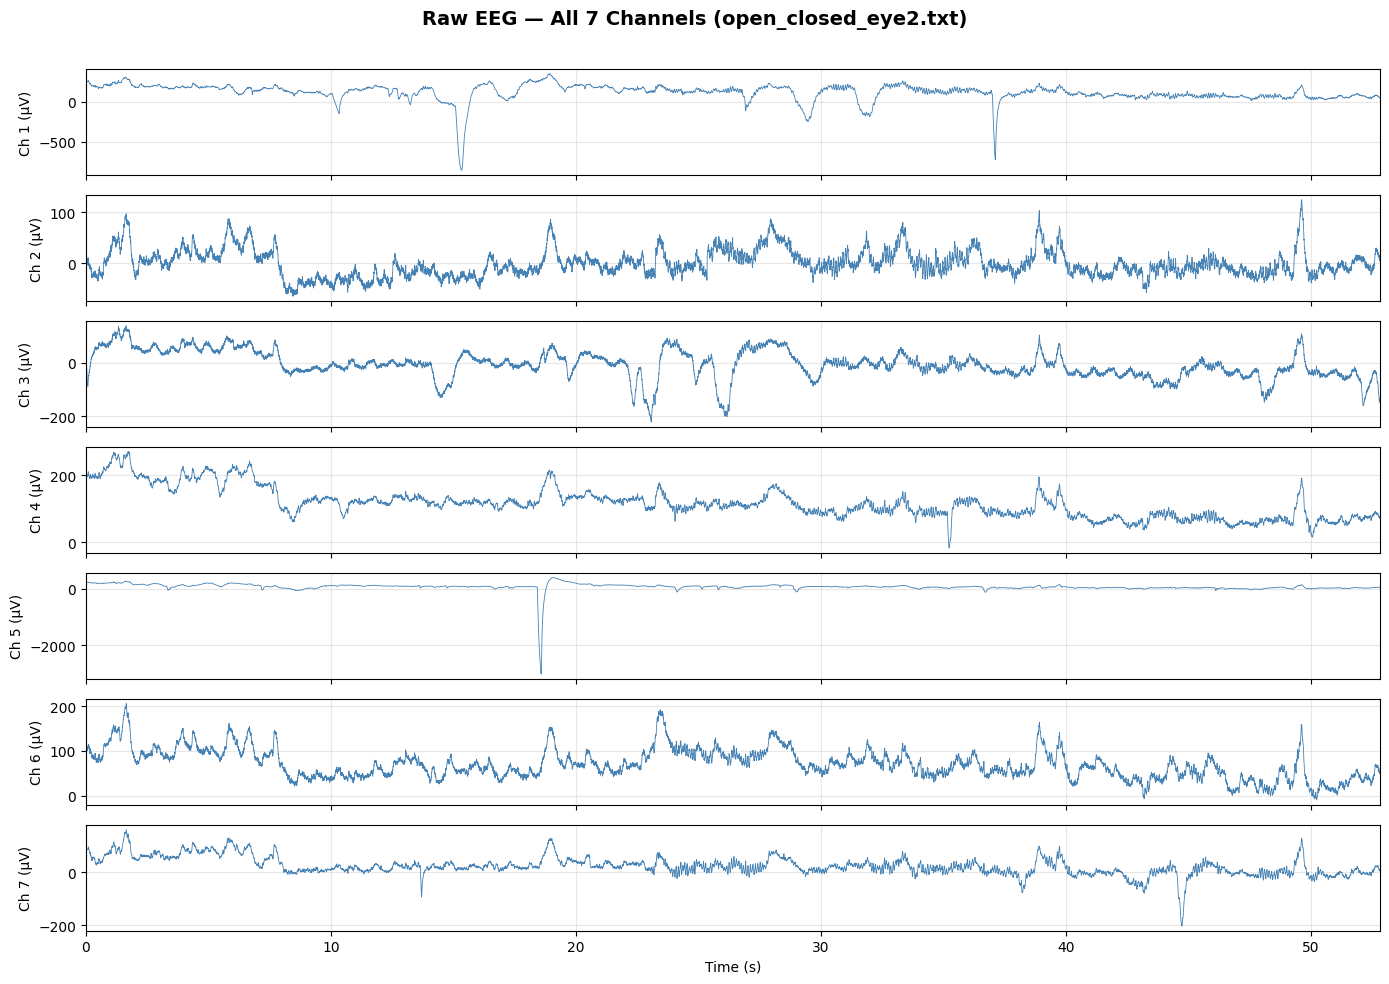

In [10]:
fs = 250
time_axis_raw = np.arange(n_samples_raw) / fs

fig, axes = plt.subplots(n_channels, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Raw EEG — All 7 Channels (open_closed_eye2.txt)", fontsize=14, fontweight="bold")

for ch in range(n_channels):
    ax = axes[ch]
    ax.plot(time_axis_raw, raw_data[ch, :], color="steelblue", linewidth=0.6)
    ax.set_ylabel(f"Ch {ch+1} (μV)")
    ax.set_xlim(time_axis_raw[0], time_axis_raw[-1])
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Step 4: Signal Quality Check & Cleaning

We run the quality-check pipeline to detect 50 Hz interference, EMG artifacts, and outliers.  
Noisy segments are removed to produce a **cleaned dataset** that will be used for all subsequent Alpha analyses.


Running EEG quality check...
Applying bandpass filter (1-100Hz)...
Start processing data: 7 channels, 52 segments (250 points per segment)...


c:\Users\36254\anaconda3\envs\neuradock\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


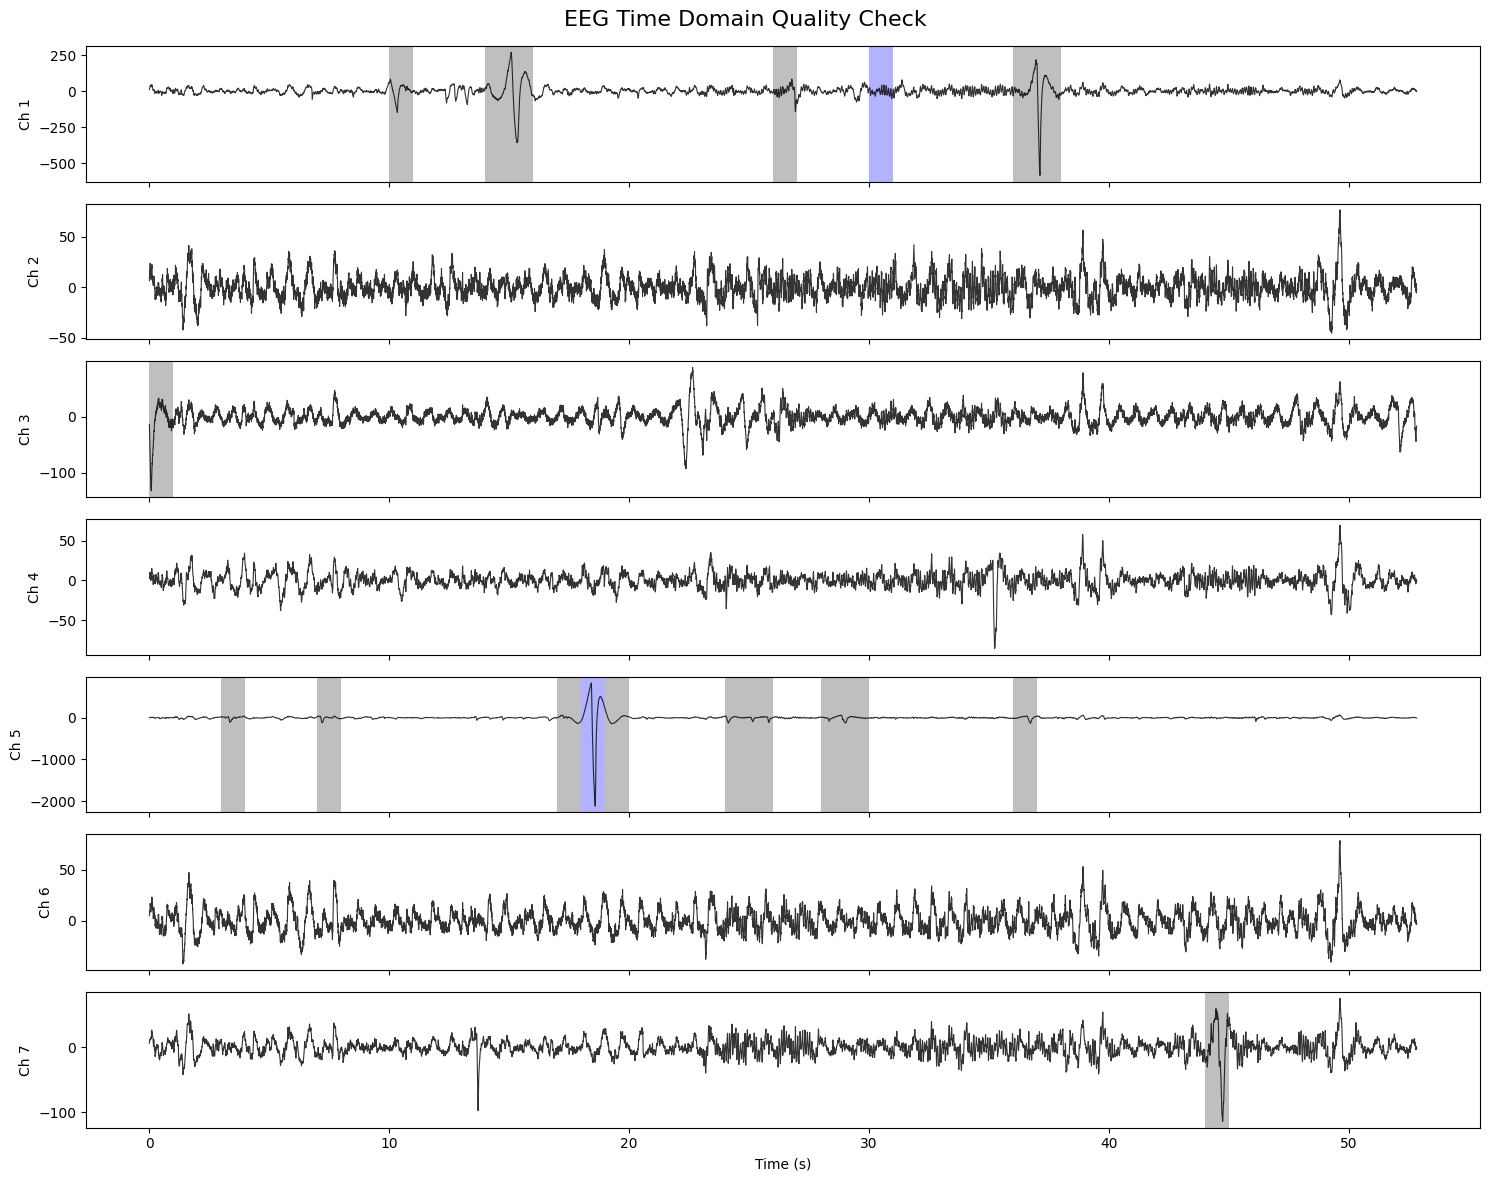

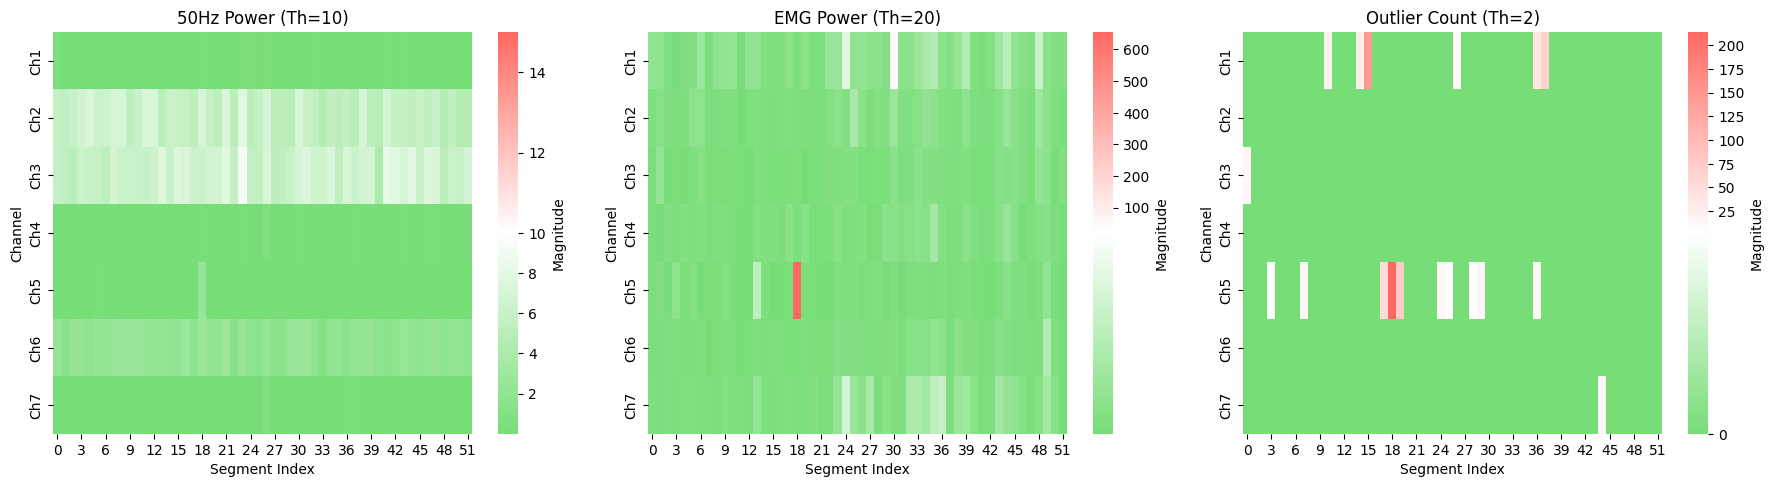


Running data cleaning...
Detection results:
  - Bad channel indices (noise ratio > 40.0%): []
  - Good channel indices: [0 1 2 3 4 5 6]
Data cleaning complete: original length 13210 -> cleaned 8710
Information retention rate: 65.93%

Visualization: Raw vs. Cleaned


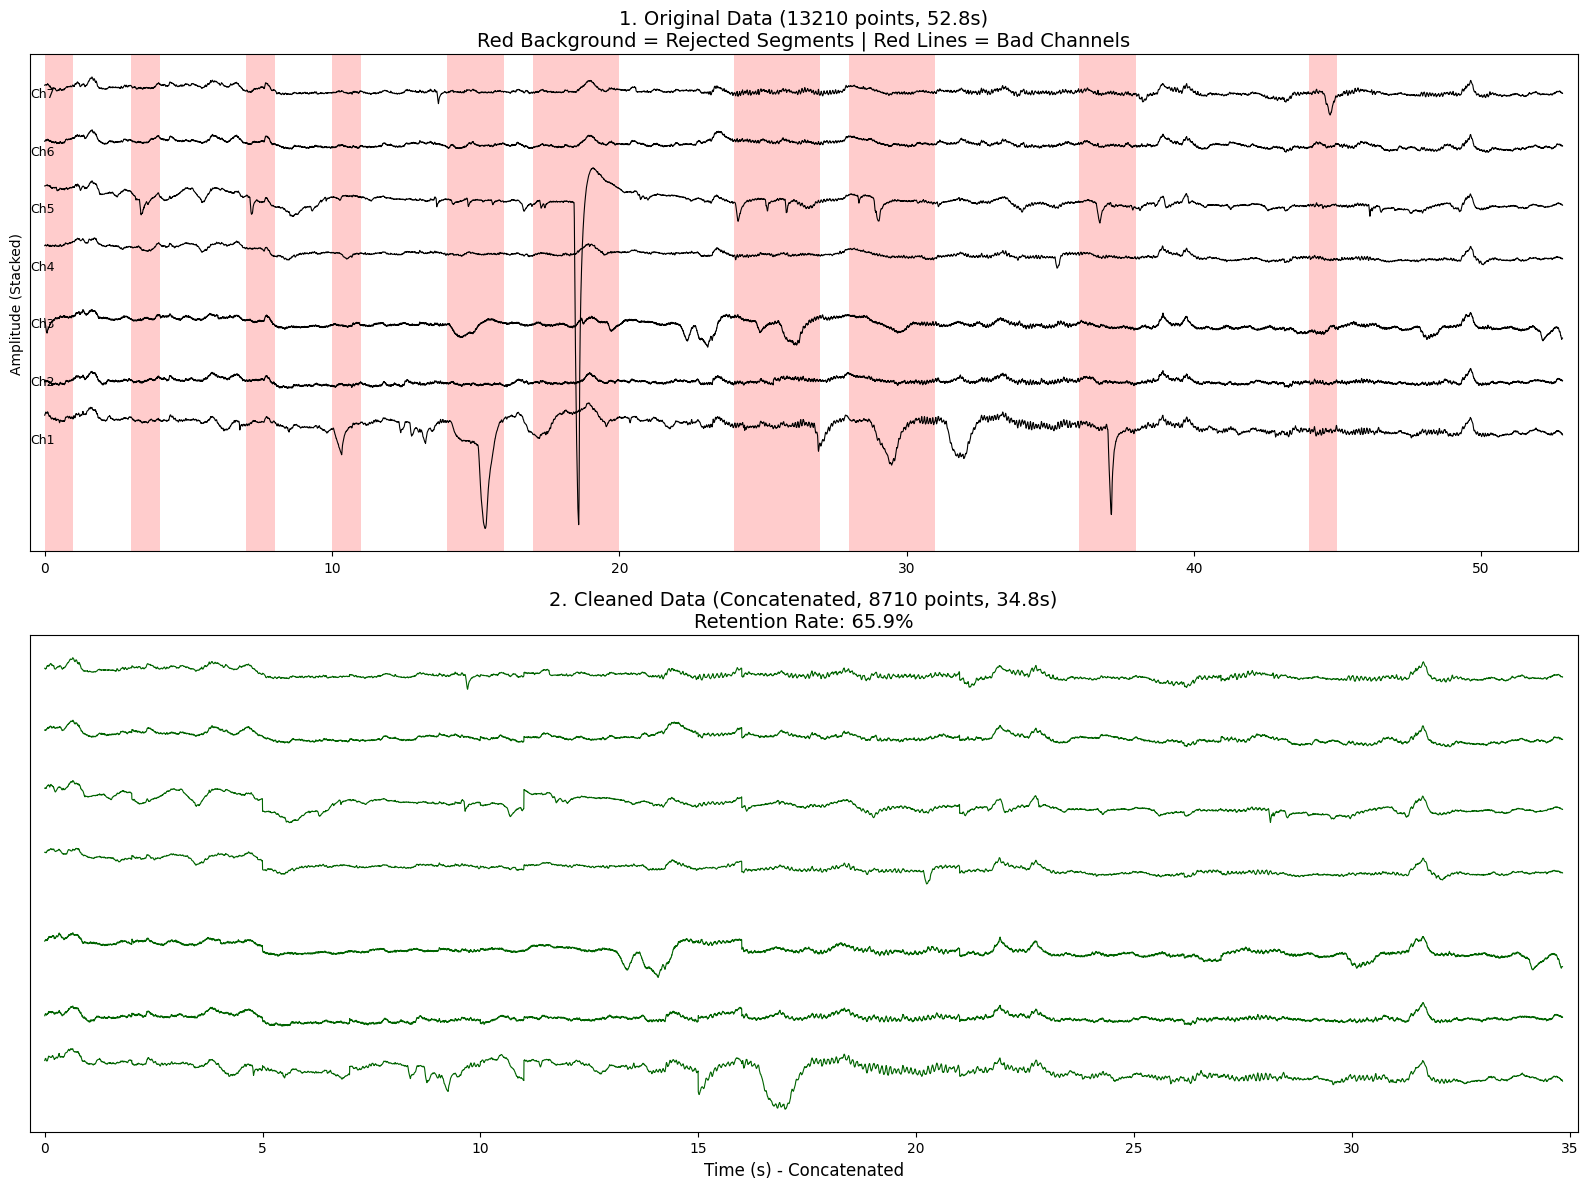


Clean data shape : (7, 8710)
Working duration : 34.84 s


In [11]:
# ------------------------------------------------------------------
# Quality check + cleaning
# ------------------------------------------------------------------
print("Running EEG quality check...")
metrics = eeg_quality_check(raw_data, fs=250)

print("\nRunning data cleaning...")
clean_data, keep_mask, info = clean_eeg_data(raw_data, metrics, thresh=[10, 20, 2])

print("\nVisualization: Raw vs. Cleaned")
visualize_cleaning_comparison(raw_data, clean_data, keep_mask, info, fs=250)

# Update working variables to cleaned data for the rest of the notebook
n_samples = clean_data.shape[1]
time_axis = np.arange(n_samples) / fs
print(f"\nClean data shape : {clean_data.shape}")
print(f"Working duration : {n_samples / fs:.2f} s")


## Step 5: Comprehensive Alpha Analysis (Cleaned Data)

`analyze_alpha_and_plot_eeg_group` performs the full analysis pipeline automatically on the **cleaned data**:
- Band-pass filters the signal to the Alpha band (8–13 Hz)
- Computes the Hilbert envelope to track Alpha amplitude over time
- Automatically determines a threshold (50th percentile) to separate **eyes-closed** (high Alpha) from **eyes-open** (low Alpha) segments
- Extracts 2-second zoom windows around the maximum and minimum envelope points
- Computes Alpha-band SNR for all 7 channels
- Generates a 5-panel publication-quality figure


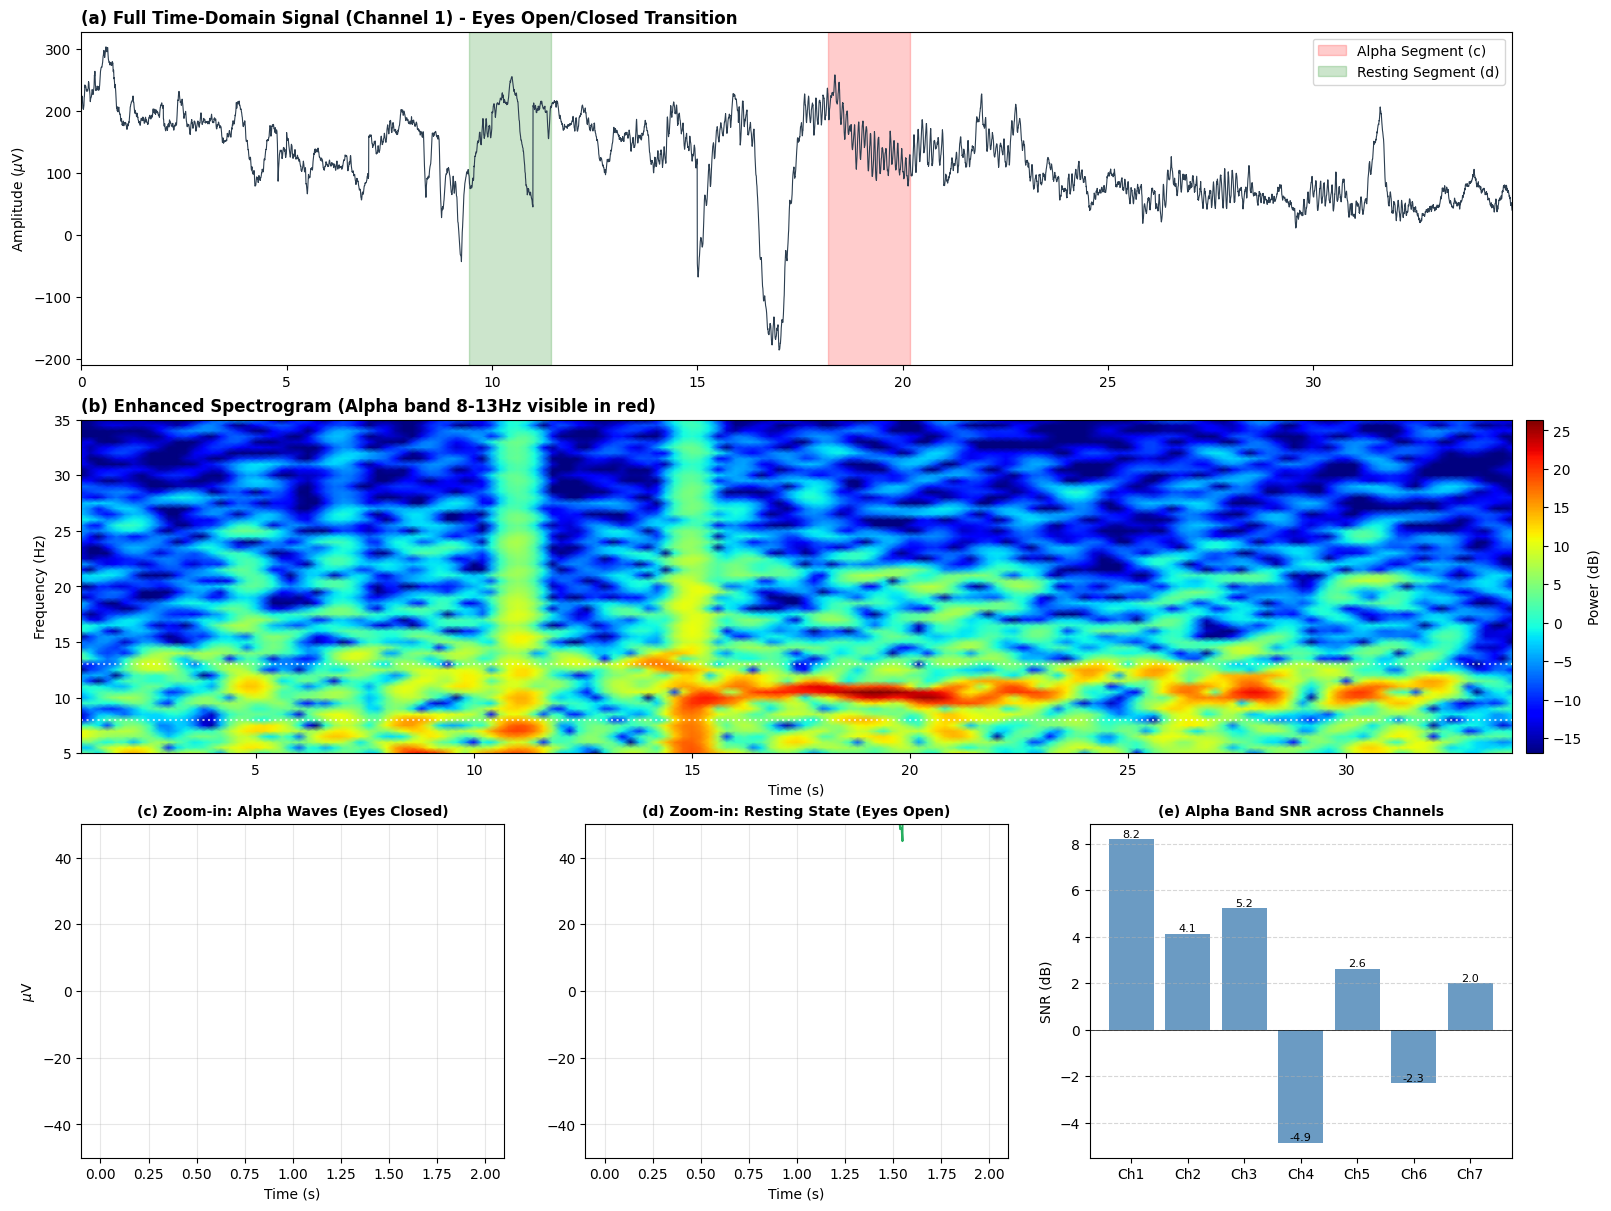

In [12]:
# Run the built-in comprehensive Alpha analysis on CLEANED data
# show_channel=0 means Channel 1 (O1 or closest occipital channel) is used for the main plots
analyze_alpha_and_plot_eeg_group(clean_data, fs=250, show_channel=0)


## Step 6: Quantitative Comparison — PSD & Multi-Channel Alpha Power

The automatic plot above gives a qualitative view. Here we perform a quantitative comparison on the **cleaned data**:
1. Use the same envelope-based segmentation to label every sample as **Eyes-Closed (EC)** or **Eyes-Open (EO)**.
2. Compute average Welch PSD for the EC and EO periods.
3. Compare Alpha power (8–13 Hz) across all 7 channels.


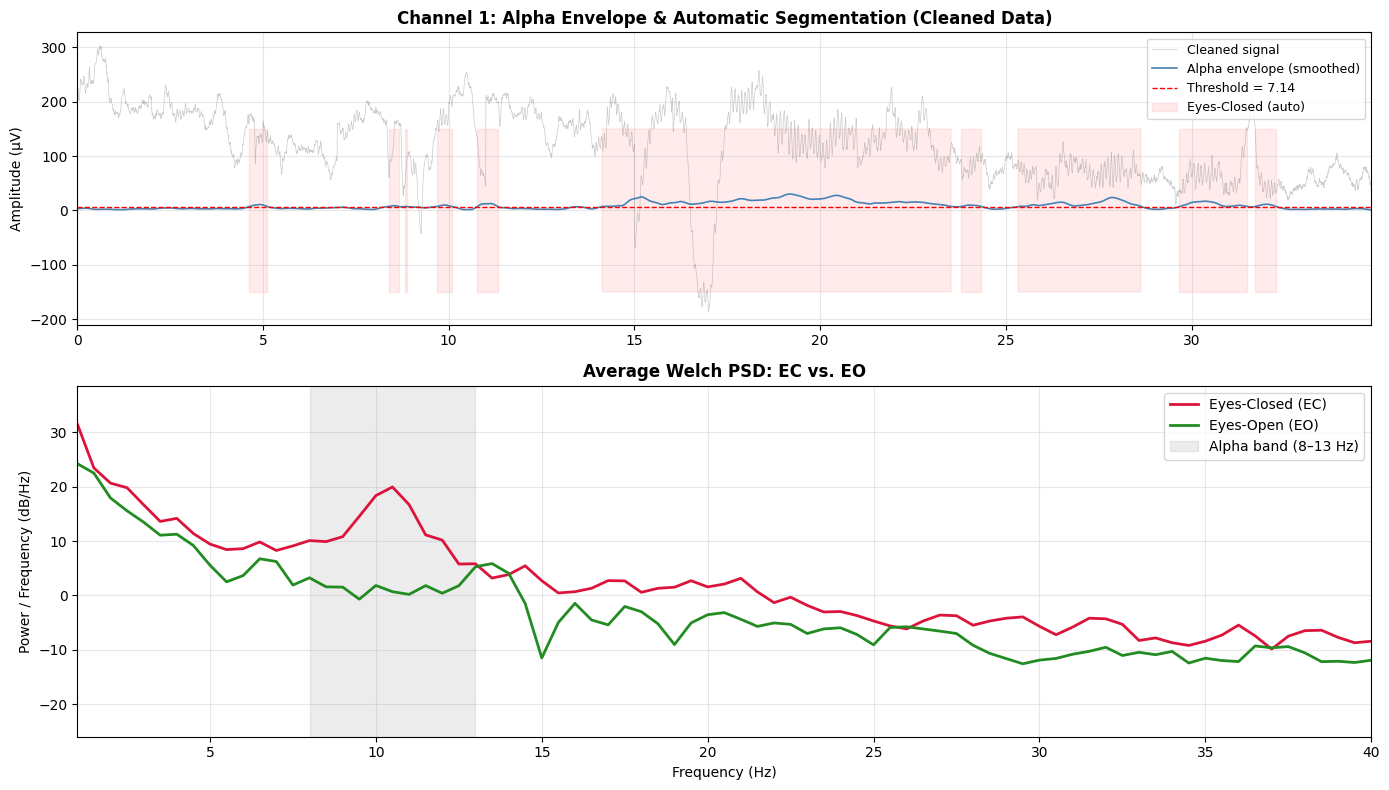

Quantitative Alpha Comparison (Channel 1):
  Mean Alpha Power (8–13 Hz) — Eyes-Closed : 27.85 μV²/Hz
  Mean Alpha Power (8–13 Hz) — Eyes-Open   : 1.55 μV²/Hz
  Ratio (EC / EO)                           : 18.0×


In [13]:
# ------------------------------------------------------------------
# Replicate the envelope / threshold logic for custom stats on clean data
# ------------------------------------------------------------------
fs = 250
ch = 0  # Use Channel 1 for the segmentation reference
eeg_sig = clean_data[ch, :]

# Alpha band filter (8-13 Hz)
b, a = signal.butter(4, [8, 13], btype="bandpass", fs=fs)
alpha_filt = signal.filtfilt(b, a, eeg_sig)

# Hilbert envelope
analytic = signal.hilbert(alpha_filt)
envelope = np.abs(analytic)

# Smooth envelope (0.5 s moving average)
win = int(fs * 0.5)
envelope_smooth = np.convolve(envelope, np.ones(win) / win, mode="same")

# 50th-percentile threshold (same logic as analyze_alpha_and_plot_eeg_group)
threshold = np.percentile(envelope_smooth, 50)
ec_mask = envelope_smooth > threshold   # Eyes-Closed (high Alpha)
eo_mask = envelope_smooth <= threshold  # Eyes-Open (low Alpha)

# ------------------------------------------------------------------
# Helper: compute average Welch PSD from all continuous EC / EO segments
# ------------------------------------------------------------------
def avg_psd_from_mask(data_ch, fs, mask, min_len_sec=2):
    """Average PSD across all valid continuous segments."""
    min_len = int(min_len_sec * fs)
    psds = []
    in_seg = False
    start = 0
    for i in range(len(mask)):
        if mask[i] and not in_seg:
            start = i
            in_seg = True
        elif not mask[i] and in_seg:
            seg = data_ch[start:i]
            if len(seg) >= min_len:
                f, psd = signal.welch(seg, fs, nperseg=min_len)
                psds.append(psd)
            in_seg = False
    if in_seg:
        seg = data_ch[start:]
        if len(seg) >= min_len:
            f, psd = signal.welch(seg, fs, nperseg=min_len)
            psds.append(psd)
    if not psds:
        return None, None
    return f, np.mean(psds, axis=0)

# Compute PSDs for EC and EO
f_psd, psd_ec = avg_psd_from_mask(eeg_sig, fs, ec_mask)
f_psd, psd_eo = avg_psd_from_mask(eeg_sig, fs, eo_mask)

# ------------------------------------------------------------------
# Plot 1: Envelope + segmentation overlay
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [1, 1.2]})

# (a) Raw + envelope
ax = axes[0]
ax.plot(time_axis, eeg_sig, color="gray", alpha=0.4, linewidth=0.5, label="Cleaned signal")
ax.plot(time_axis, envelope_smooth, color="steelblue", linewidth=1.2, label="Alpha envelope (smoothed)")
ax.axhline(threshold, color="red", linestyle="--", linewidth=1, label=f"Threshold = {threshold:.2f}")
ax.fill_between(time_axis, -150, 150, where=ec_mask, color="red", alpha=0.08, label="Eyes-Closed (auto)")
ax.set_ylabel("Amplitude (μV)")
ax.set_title(f"Channel {ch+1}: Alpha Envelope & Automatic Segmentation (Cleaned Data)", fontweight="bold")
ax.set_xlim(time_axis[0], time_axis[-1])
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

# (b) PSD comparison
ax = axes[1]
ax.plot(f_psd, 10 * np.log10(psd_ec), color="crimson", linewidth=2, label="Eyes-Closed (EC)")
ax.plot(f_psd, 10 * np.log10(psd_eo), color="forestgreen", linewidth=2, label="Eyes-Open (EO)")
ax.axvspan(8, 13, color="gray", alpha=0.15, label="Alpha band (8–13 Hz)")
ax.set_xlim(1, 40)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power / Frequency (dB/Hz)")
ax.set_title("Average Welch PSD: EC vs. EO", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
alpha_idx = (f_psd >= 8) & (f_psd <= 13)
p_alpha_ec = np.mean(psd_ec[alpha_idx])
p_alpha_eo = np.mean(psd_eo[alpha_idx])
print("=" * 50)
print("Quantitative Alpha Comparison (Channel {}):".format(ch + 1))
print("  Mean Alpha Power (8–13 Hz) — Eyes-Closed : {:.2f} μV²/Hz".format(p_alpha_ec))
print("  Mean Alpha Power (8–13 Hz) — Eyes-Open   : {:.2f} μV²/Hz".format(p_alpha_eo))
print("  Ratio (EC / EO)                           : {:.1f}×".format(p_alpha_ec / p_alpha_eo))
print("=" * 50)


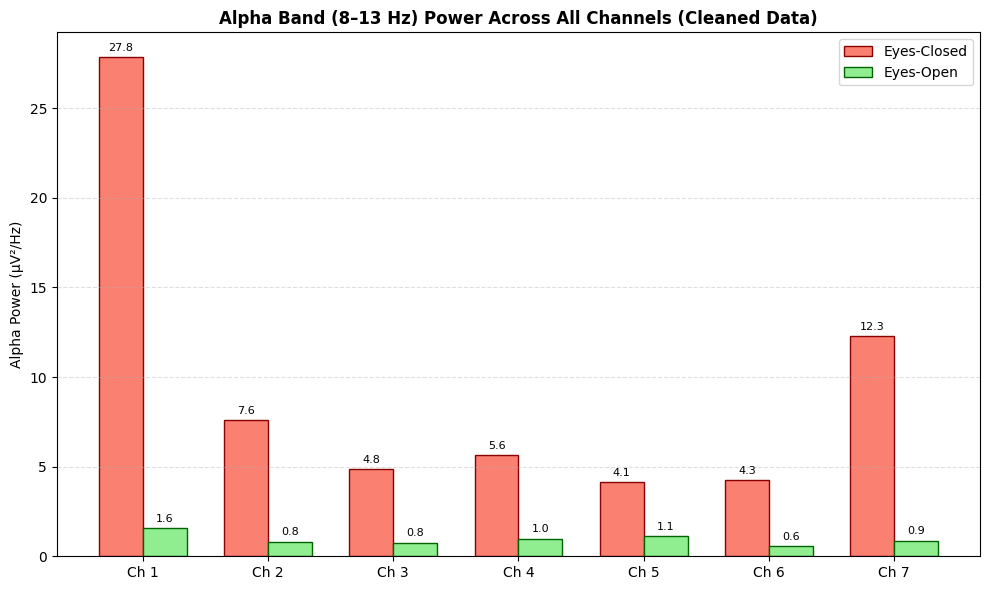

In [14]:
# ------------------------------------------------------------------
# Multi-channel Alpha power bar chart (cleaned data)
# ------------------------------------------------------------------
alpha_powers_ec = []
alpha_powers_eo = []

for ch_i in range(n_channels):
    _, psd_ec_ch = avg_psd_from_mask(clean_data[ch_i, :], fs, ec_mask)
    _, psd_eo_ch = avg_psd_from_mask(clean_data[ch_i, :], fs, eo_mask)
    alpha_idx = (f_psd >= 8) & (f_psd <= 13)
    alpha_powers_ec.append(np.mean(psd_ec_ch[alpha_idx]))
    alpha_powers_eo.append(np.mean(psd_eo_ch[alpha_idx]))

x = np.arange(n_channels)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width / 2, alpha_powers_ec, width, label="Eyes-Closed", color="salmon", edgecolor="darkred")
bars2 = ax.bar(x + width / 2, alpha_powers_eo, width, label="Eyes-Open", color="lightgreen", edgecolor="darkgreen")

ax.set_ylabel("Alpha Power (μV²/Hz)")
ax.set_title("Alpha Band (8–13 Hz) Power Across All Channels (Cleaned Data)", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"Ch {i+1}" for i in range(n_channels)])
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Annotate bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()
